# Colab setup

Run these cells first in Google Colab, then continue with the notebook body below. The notebook body is kept in the same order as `EKFs_Main_Results.ipynb`.

In [7]:
# Install Colab dependencies. Run this cell first.
# If Colab restarts after installation, run this cell once more before continuing.
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SETUP_MARKER = Path(".colab_setup_complete_v2_numba")
COLAB_PACKAGES = [
    "numpy==2.2.6",
    "scipy==1.15.3",
    "pandas==2.2.3",
    "numba>=0.61.2",
    "wntr>=1.3",
    "viswaternet>=2.2",
    "ptitprince>=0.2.7",
    "openpyxl>=3.1",
]

def run_pip(args):
    cmd = [sys.executable, "-m", "pip", *args]
    print()
    print("$", " ".join(cmd))
    result = subprocess.run(cmd, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(result.stdout)
    if result.returncode != 0:
        raise RuntimeError(f"pip failed with exit code {result.returncode}")

if IN_COLAB and not SETUP_MARKER.exists():
    print("Installing/upgrading Colab packages. This may take a few minutes.")
    run_pip(["install", "--upgrade", "pip", "setuptools", "wheel"])
    run_pip(["install", "--upgrade", "--no-cache-dir", *COLAB_PACKAGES])
    SETUP_MARKER.write_text("done")
    print("Package installation finished. Restarting the Colab runtime now.")
    print("After Colab reconnects, run this setup cell again, then continue.")
    os.kill(os.getpid(), 9)
elif IN_COLAB:
    print("Colab package setup has already completed for this runtime session.")
else:
    print("Not running in Colab; skipping package installation.")


Colab package setup has already completed for this runtime session.


In [9]:
import shutil
from pathlib import Path

shutil.rmtree("/content/EKF_SE_open_source", ignore_errors=True)
Path("/content/EKF_SE_open_source.zip").unlink(missing_ok=True)
print("old project files removed")

old project files removed


In [12]:
# Locate or upload the local project files used by the notebook.
# Required files/folders: pipedream_solver/, C-Town.inp, CTOWN_map.inp,
# pipedream_utility.py, pipedream_simulation_sensor_results.py,
# pipedream_simulation.py, ctown_EKF_BC.py.
from pathlib import Path
import os
import sys
import zipfile

PROJECT_ROOT_OVERRIDE = None  # Example: "/content/EKF_SE_open_source"
PROJECT_ZIP_NAME = "EKF_SE_open_source.zip"
PROJECT_MARKERS = [
    "pipedream_solver",
    "C-Town.inp",
    "CTOWN_map.inp",
    "pipedream_utility.py",
    "pipedream_simulation_sensor_results.py",
    "pipedream_simulation.py",
    "ctown_EKF_BC.py",
]

def has_project_markers(path):
    path = Path(path)
    return all((path / marker).exists() for marker in PROJECT_MARKERS)

def zip_has_project_markers(zip_path):
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            names = {name.replace("\\", "/") for name in zf.namelist()}
    except zipfile.BadZipFile:
        return False

    root_candidates = {name.split("/")[0] for name in names if "/" in name}
    for root in root_candidates:
        required = {
            f"{root}/C-Town.inp",
            f"{root}/CTOWN_map.inp",
            f"{root}/pipedream_utility.py",
            f"{root}/pipedream_simulation_sensor_results.py",
            f"{root}/pipedream_simulation.py",
            f"{root}/ctown_EKF_BC.py",
        }
        has_solver = any(name.startswith(f"{root}/pipedream_solver/") for name in names)
        if has_solver and required.issubset(names):
            return True
    return False

def describe_content_tree(root=Path("/content"), max_items=120):
    print(f"Current working directory: {Path.cwd()}")
    print(f"Listing likely upload locations under {root}:")
    shown = 0
    if root.exists():
        for path in sorted(root.rglob("*")):
            if shown >= max_items:
                print(f"... output truncated after {max_items} items")
                break
            rel = path.relative_to(root)
            depth = len(rel.parts)
            if depth <= 3 and ".ipynb_checkpoints" not in path.parts:
                kind = "dir " if path.is_dir() else "file"
                size = f" ({path.stat().st_size} bytes)" if path.is_file() else ""
                print(f"  {kind} /{rel.as_posix()}{size}")
                shown += 1

def upload_project_zip():
    try:
        from google.colab import files  # type: ignore
    except Exception:
        return None
    print(f"Please upload the current {PROJECT_ZIP_NAME} file.")
    uploaded = files.upload()
    if PROJECT_ZIP_NAME not in uploaded:
        print(f"Uploaded files: {list(uploaded.keys())}")
        return None
    return Path("/content") / PROJECT_ZIP_NAME

def unzip_project_if_available():
    zip_candidates = [Path.cwd() / PROJECT_ZIP_NAME, Path("/content") / PROJECT_ZIP_NAME]

    for zip_path in zip_candidates:
        if zip_path.exists():
            if not zip_has_project_markers(zip_path):
                print(f"Found {zip_path}, but it does not contain the required current project files.")
                print("This is probably an old zip. Please upload the current zip.")
                try:
                    zip_path.unlink()
                except Exception:
                    pass
                break
            print(f"Found {zip_path}; extracting to /content ...")
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall("/content")
            return True

    zip_path = upload_project_zip()
    if zip_path is None:
        return False
    if not zip_has_project_markers(zip_path):
        print(f"Uploaded {zip_path}, but it still does not contain the required project files.")
        return False
    print(f"Extracting {zip_path} to /content ...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall("/content")
    return True

def search_for_project_root():
    if PROJECT_ROOT_OVERRIDE:
        override = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if has_project_markers(override):
            return override
        raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE is set to {override}, but required files were not found there.")

    candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    candidates += [
        Path("/content/EKF_SE_open_source"),
        Path("/content/drive/MyDrive/EKF_SE_open_source"),
        Path("/content/drive/MyDrive/Colab Notebooks/EKF_SE_open_source"),
    ]
    for candidate in candidates:
        if candidate.exists() and has_project_markers(candidate):
            return candidate

    for root in [Path("/content"), Path("/content/drive/MyDrive")]:
        if not root.exists():
            continue
        for solver_dir in root.rglob("pipedream_solver"):
            project_root = solver_dir.parent
            if has_project_markers(project_root):
                return project_root
    return None

PROJECT_ROOT = search_for_project_root()
if PROJECT_ROOT is None and unzip_project_if_available():
    PROJECT_ROOT = search_for_project_root()

if PROJECT_ROOT is None:
    describe_content_tree()
    raise FileNotFoundError(
        "Could not find project files. Upload the current EKF_SE_open_source.zip, or set PROJECT_ROOT_OVERRIDE."
    )

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Path("figs").mkdir(exist_ok=True)
print(f"Working directory: {PROJECT_ROOT}")
for marker in PROJECT_MARKERS:
    print(f"{marker}: {(PROJECT_ROOT / marker).exists()}")


Please upload the current EKF_SE_open_source.zip file.


Saving EKF_SE_open_source.zip to EKF_SE_open_source.zip
Extracting /content/EKF_SE_open_source.zip to /content ...
Working directory: /content/EKF_SE_open_source
pipedream_solver: True
C-Town.inp: True
CTOWN_map.inp: True
pipedream_utility.py: True
pipedream_simulation_sensor_results.py: True
pipedream_simulation.py: True
ctown_EKF_BC.py: True


# Setup

In [13]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wntr
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
from pipedream_solver.nutils import interpolate_sample
import pipedream_utility as pdu
from pipedream_utility import *
import pipedream_simulation as pd_sim
from pipedream_simulation import run_pipedream_simulation
import viswaternet as vis
import math
import time

#Don't show future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

dt = 1800
t_run = 24

inp = 'C-Town.inp'
wn = wntr.network.WaterNetworkModel(inp)

# Run hydraulic model (uncertainy included)

In [15]:
# run hydraulic simulation using pipedream
t1 = time.time()
H_df_model, Q_df_model, Q_o_model, Q_pump_model, Q_prv_model, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult_model = run_pipedream_simulation(inp, t_run = t_run, dt = dt, banded = False)
t2 = time.time()

print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

0 0.0
0 1800.0
1 3600.0
1 5400.0
2 7200.0
2 9000.0
3 10800.0
3 12600.0
4 14400.0
4 16200.0
5 18000.0
5 19800.0
6 21600.0
6 23400.0
7 25200.0
7 27000.0
8 28800.0
8 30600.0
9 32400.0
9 34200.0
10 36000.0
10 37800.0
11 39600.0
11 41400.0
12 43200.0
12 45000.0
13 46800.0
13 48600.0
14 50400.0
14 52200.0
15 54000.0
15 55800.0
16 57600.0
16 59400.0
17 61200.0
17 63000.0
18 64800.0
18 66600.0
19 68400.0
19 70200.0
20 72000.0
20 73800.0
21 75600.0
21 77400.0
22 79200.0
22 81000.0
23 82800.0
23 84600.0
Pipedream RUN:9.035118579864502 seconds


## Choose sensor locations

In [14]:
imp_list = []#['J317', 'J269', 'J415', 'J302', 'J306', 'J14'] # boundary condition
head_sensors = ['J67',  'J269','J256','J289','J415','J306','J307','J317',  'J14',  'J35','J253']
tank_sensors = wn.tank_name_list
flow_sensors = ['P467', 'P310', 'P796', 'P237', 'P424', 'P409']

## Generate synthetic ground truth

In [16]:
from pipedream_simulation_sensor_results import run_pipedream_simulation_sensor
t1 = time.time()
H_df_groundtruth, Q_df_groundtruth, H_df_sensor, Q_df_sensor, Q_o_sensor, Q_pump_sensor, Q_prv_sensor, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult_sensor = run_pipedream_simulation_sensor(inp, t_run = t_run, dt = dt, banded = False)
t2 = time.time()
print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

0 0.0
0 1800.0
1 3600.0
1 5400.0
2 7200.0
2 9000.0
3 10800.0
3 12600.0
4 14400.0
4 16200.0
5 18000.0
5 19800.0
6 21600.0
6 23400.0
7 25200.0
7 27000.0
8 28800.0
8 30600.0
9 32400.0
9 34200.0
10 36000.0
10 37800.0
11 39600.0
11 41400.0
12 43200.0
12 45000.0
13 46800.0
13 48600.0
14 50400.0
14 52200.0
15 54000.0
15 55800.0
16 57600.0
16 59400.0
17 61200.0
17 63000.0
18 64800.0
18 66600.0
19 68400.0
19 70200.0
20 72000.0
20 73800.0
21 75600.0
21 77400.0
22 79200.0
22 81000.0
23 82800.0
23 84600.0
Pipedream RUN:12.340918779373169 seconds


# (1) Corr-EKF:

In [17]:
# Use the COV and CORR from the model results
# COV matrix for the flows
Q_corr_matrix = Q_df_model.corr()
Q_cov_matrix = Q_df_model.cov()
Q_cov_mask = Q_corr_matrix.abs() > 0.9
Q_cov_matrix = Q_cov_matrix.where(Q_cov_mask, other=0)
Q_cov_array = Q_cov_matrix.to_numpy()

Q_cov_sign = np.tile(flip_mult_model, (len(flip_mult_model), 1))
Q_cov_sign = Q_cov_sign * flip_mult_model[:, np.newaxis]
Q_cov_array_sign = Q_cov_sign * Q_cov_array
# COV matrix for the nodes
H_corr_matrix = H_df_model.corr()
H_cov_matrix = H_df_model.cov()
H_cov_mask = H_corr_matrix.abs() > 0.9
H_cov_matrix = H_cov_matrix.where(H_cov_mask, other=0)
H_cov_array = H_cov_matrix.to_numpy()
#
Q_Hj_cov =  H_cov_array
Q_Quk_cov = (0.01**2) * np.eye(len(superlinks))
Q_Qdk_cov = (0.01**2) * np.eye(len(superlinks))
Q_Qo_cov = (0.01**2) * np.eye(len(orifices))
Q_Qpump_cov = (0.01**2) * np.eye(len(pumps))
Q_Qprv_cov = (0.01**2) * np.eye(len(prvs))
Q_hIk_cov = (5**2) * np.eye(len(superlinks)*2)
Q_Qik_cov = Q_cov_array_sign
from scipy.linalg import block_diag
Qcov = block_diag(Q_Hj_cov, Q_Quk_cov, Q_Qdk_cov, Q_Qo_cov, Q_Qpump_cov, Q_Qprv_cov, Q_hIk_cov, Q_Qik_cov)
R_head_sensor_cov = (0.5**2) * np.eye(len(head_sensors))
R_tank_sensor_cov = (0.2**2) * np.eye(len(tank_sensors))
R_flow_sensor_cov = (0.002**2) * np.eye(len(flow_sensors))
Rcov = block_diag(R_head_sensor_cov, R_tank_sensor_cov, R_flow_sensor_cov)

In [18]:
bc_choose = imp_list
head_sensor_list = [superjunctions['name'].to_list().index(s) for s in head_sensors]
bc_list = [superjunctions['name'].to_list().index(s) for s in bc_choose]
bc_measurements = pd.DataFrame(H_df_sensor.iloc[:,bc_list].copy())
known_measurements_list = [superjunctions['name'].to_list().index(s) for s in wn.tank_name_list]
msmts = head_sensor_list + known_measurements_list
flow_list=[superlinks['name'].to_list().index(s) for s in flow_sensors]

measurements = pd.concat([H_df_sensor.iloc[:,msmts].copy(), Q_df_sensor.iloc[:, flow_list].copy()*flip_mult_sensor[flow_list]], axis=1)
measurements.index += dt

In [19]:
from ctown_EKF_BC import apply_EKF_BC

t1 = time.time()
H_df_corr_ekf, Q_df_corr_ekf, Q_pump_corr_ekf, Q_prv_corr_ekf, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult, P_xk1k_corr_ekf, P_xk1k1_corr_ekf = apply_EKF_BC(inp, bc_choose, msmts, flow_list, bc_measurements, measurements, Qcov, Rcov, t_run = t_run, dt = dt, banded=False)
t2 = time.time()
print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

0 0.0
0 1800.0
1 3600.0
1 5400.0
2 7200.0
2 9000.0
3 10800.0
3 12600.0
4 14400.0
4 16200.0
5 18000.0
5 19800.0
6 21600.0
6 23400.0
7 25200.0
7 27000.0
8 28800.0
8 30600.0
9 32400.0
9 34200.0
10 36000.0
10 37800.0
11 39600.0
11 41400.0
12 43200.0
12 45000.0
13 46800.0
13 48600.0
14 50400.0
14 52200.0
15 54000.0
15 55800.0
16 57600.0
16 59400.0
17 61200.0
17 63000.0
18 64800.0
18 66600.0
19 68400.0
19 70200.0
20 72000.0
20 73800.0
21 75600.0
21 77400.0
22 79200.0
22 81000.0
23 82800.0
23 84600.0
Pipedream RUN:526.9866480827332 seconds


save resultls if run the above for the first time

In [ ]:
import pickle
import os
from datetime import date

save_dir = f"Results {date.today():%Y.%m.%d}"
os.makedirs(save_dir, exist_ok=True)  # create folder if not existing

# list
variables = {
    "imp_list": imp_list,
    "head_sensors": head_sensors,
    "flow_sensors": flow_sensors,
    "tank_sensors":tank_sensors,
    "H_df_model": H_df_model,
    "Q_df_model": Q_df_model,
    "Q_o_model": Q_o_model,
    "Q_pump_model": Q_pump_model,
    "Q_prv_model": Q_prv_model,
    "H_df_groundtruth": H_df_groundtruth,
    "Q_df_groundtruth": Q_df_groundtruth,
    "H_df_sensor": H_df_sensor,
    "Q_df_sensor": Q_df_sensor,
    "Q_o_sensor": Q_o_sensor,
    "Q_pump_sensor": Q_pump_sensor,
    "Q_prv_sensor": Q_prv_sensor,
    "H_df_corr_ekf": H_df_corr_ekf,
    "Q_df_corr_ekf": Q_df_corr_ekf,
    "Q_pump_corr_ekf": Q_pump_corr_ekf,
    "Q_prv_corr_ekf": Q_prv_corr_ekf,
    "superjunctions": superjunctions,
    "superlinks": superlinks,
    "P_xk1k_corr_ekf": P_xk1k_corr_ekf,
    "P_xk1k1_corr_ekf": P_xk1k1_corr_ekf
}

# save
save_path = os.path.join(save_dir, "CORREKF.pkl")
with open(save_path, "wb") as f:
    pickle.dump(variables, f)

print(f"Saved list to {save_path}！")

Run it only if you already saved results

In [ ]:
import pickle
import os
file_path = "Results 2026.06.17/CORREKF.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

H_df_groundtruth = data["H_df_groundtruth"]
H_df_sensor = data["H_df_sensor"]
H_df_model = data["H_df_model"]
H_df_corr_ekf = data["H_df_corr_ekf"]
Q_df_groundtruth = data["Q_df_groundtruth"]
Q_df_sensor = data["Q_df_sensor"]
Q_df_model = data["Q_df_model"]
Q_df_corr_ekf = data["Q_df_corr_ekf"]
imp_list = data["imp_list"]
head_sensors = data["head_sensors"]
flow_sensors = data["flow_sensors"]
P_xk1k_corr_ekf = data["P_xk1k_corr_ekf"]
P_xk1k1_corr_ekf = data["P_xk1k1_corr_ekf"]

corr EKF estimation accuracy plots

In [20]:
Q_df_model_lps = Q_df_model.copy() * 1000# transfer the unit to lps
Q_df_groundtruth_lps = Q_df_groundtruth.copy() * 1000# transfer the unit to lps
Q_df_sensor_lps = Q_df_sensor.copy() * 1000# transfer the unit to l/s
Q_df_corr_ekf_lps = Q_df_corr_ekf.copy() * 1000# transfer the unit to l/s

/usr/local/lib/python3.12/dist-packages/wntr/epanet/io.py:2082: UserWarning: Not all curves were used in "/content/EKF_SE_open_source/CTOWN_map.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


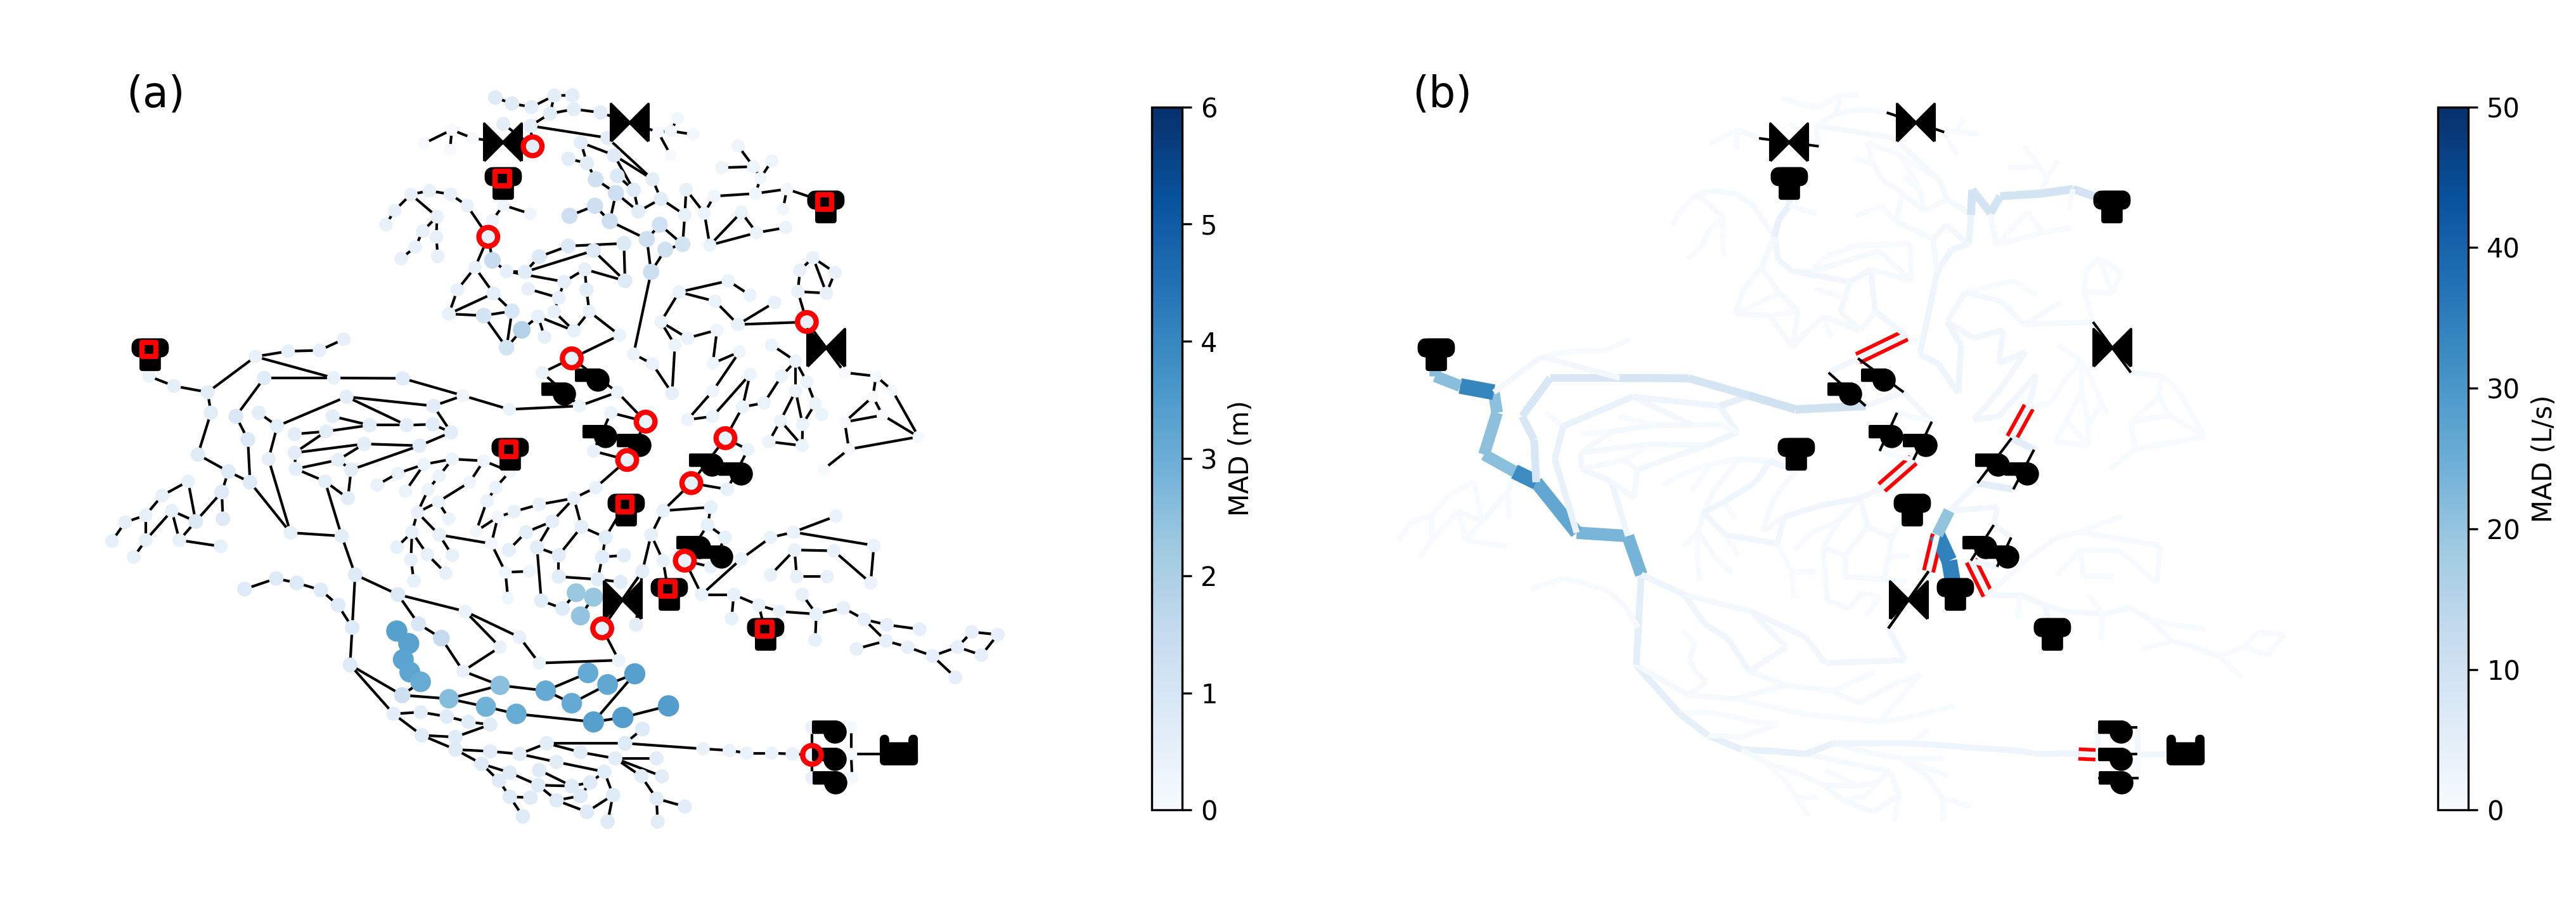

In [21]:
# plotting MAD of estimation error on the WDS map
import viswaternet as vis

vis_model = vis.VisWNModel('CTOWN_map.inp')
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
head_ekf_cov_err = np.abs(H_df_corr_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_cov_err = np.abs(Q_df_corr_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

head_max_limit = 6
flow_max_limit = 50

cmap = 'Blues'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)
style1 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'r', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)
style2 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'yellow', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, head_ekf_cov_err], data_type = 'continuous',
                                    vmin = 0, vmax=head_max_limit, style = style, color_bar_title ='MAD (m)')
vis_model.draw_nodes(ax=ax[0], node_list=list(set(head_sensors) - set(imp_list)), node_color="none", style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(tank_sensors)), node_shape = "s", node_color="none", node_size = 30, style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(imp_list)), node_color="none", style = style2)

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.draw_links(ax=ax[1], link_list=flow_sensors, link_color="red", style = style, link_width = 5)
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, flow_ekf_cov_err], data_type = 'continuous',
                           vmin = 0, vmax = flow_max_limit, style = style, color_bar_title ='MAD (L/s)')
#plt.savefig('fig_map_corr_vs_truth.pdf', dpi=400, bbox_inches="tight")

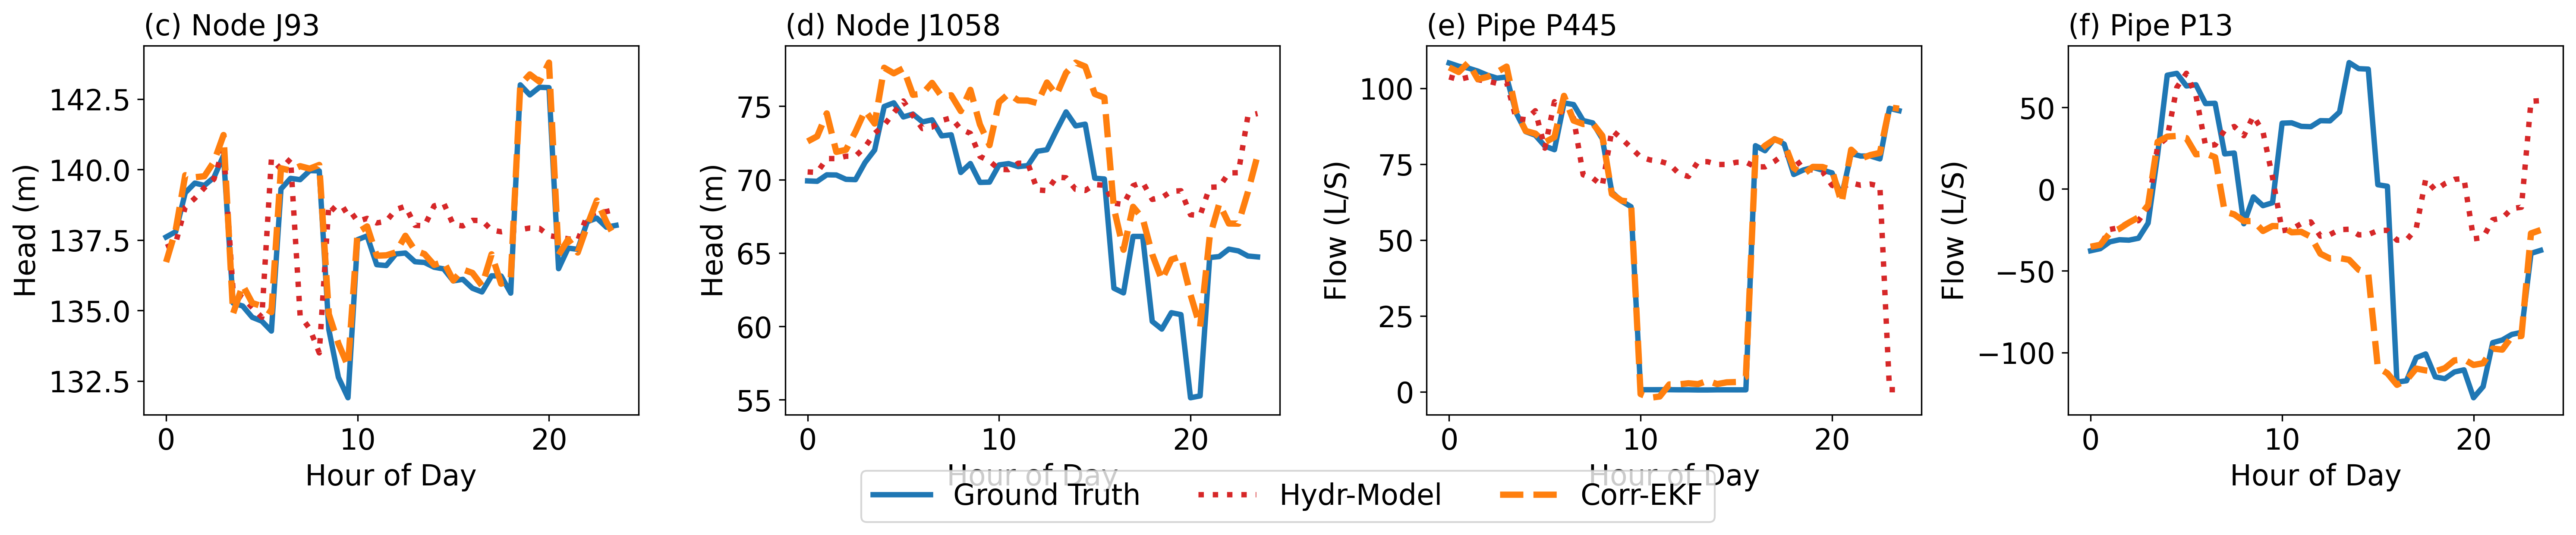

In [22]:
import string
panel_labels = list(string.ascii_lowercase[2:6])  # (c)–(h)
start_ind_wn=0
junction_names = ['J93','J1058']
link_names = ['P445','P13']
n_rows, n_cols = 1, 4

#colors = ["#1F77B4", "0.3", "#D55E00"]
colors = ["#1F77B4", "#d62728", "#ff7f0e"]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4), dpi=300)

for i in range(n_rows * n_cols):
    if i < len(junction_names):
        node = junction_names[i]
        ax.flat[i].plot(H_df_groundtruth.index[start_ind_wn:] / 3600, H_df_groundtruth[node][start_ind_wn:],
                        c=colors[0], linestyle='-', alpha=1, linewidth=3.0, label='Ground Truth')
        ax.flat[i].plot(H_df_model.index[start_ind_wn:] / 3600, H_df_model[node][start_ind_wn:],
                        c=colors[1], linestyle=':', alpha=1, linewidth=3.0, label='Hydr-Model')
        ax.flat[i].plot(H_df_corr_ekf.index[start_ind_wn:] / 3600, H_df_corr_ekf[node][start_ind_wn:],
                        c=colors[2], linestyle='--', alpha=1, linewidth=3.5, label='Corr-EKF')

        ax.flat[i].set_title(f'({panel_labels[i]}) Node {node}', fontsize=16, loc='left')
        ax.flat[i].tick_params(axis='x', labelsize=16)
        ax.flat[i].tick_params(axis='y', labelsize=16)
        ax.flat[i].set_ylabel('Head (m)', fontsize=16)
        ax.flat[i].set_xlabel('Hour of Day', fontsize=16)

    else:
        pipe = link_names[i - 2]
        ax.flat[i].plot(Q_df_groundtruth_lps.index[start_ind_wn:] / 3600, Q_df_groundtruth_lps[pipe][start_ind_wn:],
                        c=colors[0], linestyle='-', alpha=1, linewidth=3.0, label='Ground Truth')
        ax.flat[i].plot(Q_df_model_lps.index[start_ind_wn:] / 3600, Q_df_model_lps[pipe][start_ind_wn:],
                        c=colors[1], linestyle=':', alpha=1, linewidth=3.0, label='Hydr-Model')
        ax.flat[i].plot(Q_df_corr_ekf_lps.index[start_ind_wn:] / 3600, Q_df_corr_ekf_lps[pipe][start_ind_wn:],
                        c=colors[2], linestyle='--', alpha=1, linewidth=3.5, label='Corr-EKF')

        ax.flat[i].set_title(f'({panel_labels[i]}) Pipe {pipe}', fontsize=16, loc='left')
        ax.flat[i].tick_params(axis='x', labelsize=16)
        ax.flat[i].tick_params(axis='y', labelsize=16)
        ax.flat[i].set_ylabel('Flow (L/S)', fontsize=16)
        ax.flat[i].set_xlabel('Hour of Day', fontsize=16)

# legend
handles, labels = ax.flat[0].get_legend_handles_labels()

# put the legend in the bottom
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=16)
plt.tight_layout()

#plt.savefig('fig_corr_ekf_timeseries.pdf', dpi=400, bbox_inches="tight")

corr EKF estimation confidence plots

/usr/local/lib/python3.12/dist-packages/wntr/epanet/io.py:2082: UserWarning: Not all curves were used in "/content/EKF_SE_open_source/CTOWN_map.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


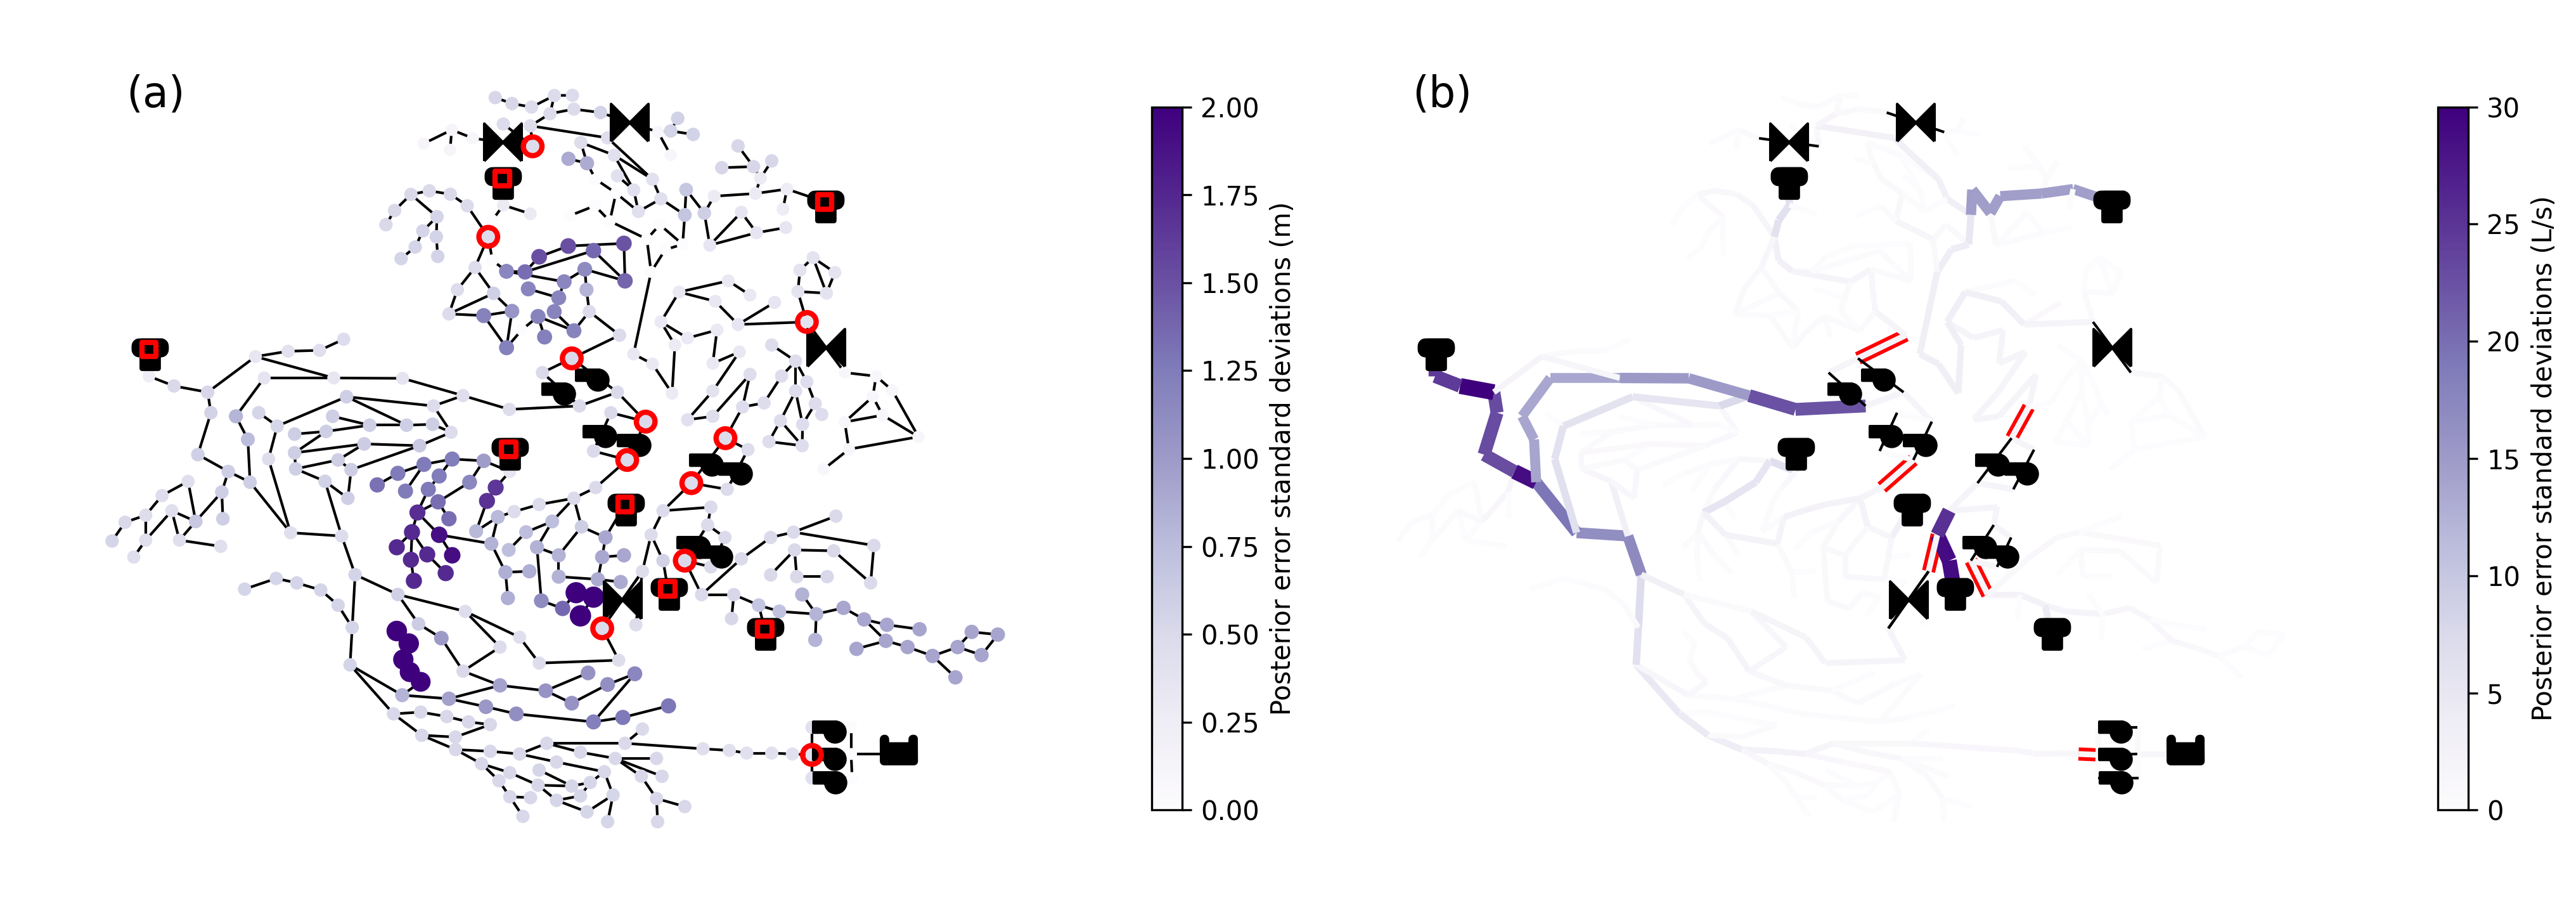

In [24]:
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
vis_model = vis.VisWNModel('CTOWN_map.inp')
Corr_head_post_diag_all = np.array([np.diag(P_xk1k1_corr_ekf[t])[:H_df_model.shape[1]] for t in range(P_xk1k1_corr_ekf.shape[0])])
Corr_flow_post_diag_all = np.array([np.diag(P_xk1k1_corr_ekf[t])[-Q_df_model.shape[1]:] for t in range(P_xk1k1_corr_ekf.shape[0])])

# match with H_df_model column name, which is the node name
Corr_head_post_diag_df = pd.DataFrame(
    Corr_head_post_diag_all,
    columns=H_df_model.columns,
    index=H_df_model.index
)

Corr_flow_post_diag_df = pd.DataFrame(
    Corr_flow_post_diag_all,
    columns=Q_df_model.columns,
    index=Q_df_model.index
)

Corr_head_post_diag_final = Corr_head_post_diag_df.iloc[-1]
Corr_flow_post_diag_final = Corr_flow_post_diag_df.iloc[-1]
Corr_head_post_diag_final = Corr_head_post_diag_final.loc[junction_names]
Corr_flow_post_diag_final = Corr_flow_post_diag_final.loc[link_names]* 1e6# transfer the unit to (l/s)^2
Corr_head_post_std_final = np.sqrt(Corr_head_post_diag_final.clip(0))
Corr_flow_post_std_final = np.sqrt(Corr_flow_post_diag_final.clip(0))

cmap = 'Purples'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)
style1 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'r', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)
style2 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'yellow', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, Corr_head_post_std_final], data_type = 'continuous',
                                   vmin=0, vmax=2, style = style, color_bar_title ='Posterior error standard deviations (m)')
vis_model.draw_nodes(ax=ax[0], node_list=list(set(head_sensors) - set(imp_list)), node_color="none", style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(tank_sensors)), node_shape = "s", node_color="none", node_size = 30, style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(imp_list)), node_color="none", style = style2)

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.draw_links(ax=ax[1], link_list=flow_sensors, link_color="red", style = style, link_width = 5)
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, Corr_flow_post_std_final], data_type = 'continuous',
                           vmin = 0, vmax = 30, style = style, color_bar_title ='Posterior error standard deviations (L/s)')
# plt.savefig('fig_map_Correkf_posterior_error.pdf', dpi=400)

# (2) B-EKF

In [2]:
# flow
Q_cov_matrix = Q_df_model.cov()
Q_var_matrix = Q_cov_matrix.copy()
Q_var_matrix.values[:] = np.diag(np.diag(Q_var_matrix.values))
Q_var_array = Q_var_matrix.to_numpy()
# head
H_cov_matrix = H_df_model.cov()
H_var_matrix = H_cov_matrix.copy()
H_var_matrix.values[:] = np.diag(np.diag(H_var_matrix.values))
H_var_array = H_var_matrix.to_numpy()

Q_Hj_cov =  H_var_array
Q_Quk_cov = (0.01**2) * np.eye(len(superlinks))
Q_Qdk_cov = (0.01**2) * np.eye(len(superlinks))
Q_Qo_cov = (0.01**2) * np.eye(len(orifices))
Q_Qpump_cov = (0.01**2) * np.eye(len(pumps))
Q_Qprv_cov = (0.01**2) * np.eye(len(prvs))
Q_hIk_cov = (5**2) * np.eye(len(superlinks)*2)
Q_Qik_cov = Q_var_array
from scipy.linalg import block_diag
Qcov = block_diag(Q_Hj_cov, Q_Quk_cov, Q_Qdk_cov, Q_Qo_cov, Q_Qpump_cov, Q_Qprv_cov, Q_hIk_cov, Q_Qik_cov)
R_head_sensor_cov = (0.5**2) * np.eye(len(head_sensors))
R_tank_sensor_cov = (0.2**2) * np.eye(len(tank_sensors))
R_flow_sensor_cov = (0.002**2) * np.eye(len(flow_sensors))
Rcov = block_diag(R_head_sensor_cov, R_tank_sensor_cov, R_flow_sensor_cov)

bc_choose = imp_list
head_sensor_list = [superjunctions['name'].to_list().index(s) for s in head_sensors]
bc_list = [superjunctions['name'].to_list().index(s) for s in bc_choose]
bc_measurements = pd.DataFrame(H_df_sensor.iloc[:,bc_list].copy())
#bc_measurements.index += dt
known_measurements_list = [superjunctions['name'].to_list().index(s) for s in wn.tank_name_list]
msmts = head_sensor_list + known_measurements_list
flow_list=[superlinks['name'].to_list().index(s) for s in flow_sensors]

measurements = pd.concat([H_df_sensor.iloc[:,msmts].copy(), Q_df_sensor.iloc[:, flow_list].copy()*flip_mult_sensor[flow_list]], axis=1)
measurements.index += dt

NameError: name 'Q_df_model' is not defined

In [1]:
from ctown_EKF_BC import apply_EKF_BC

t1 = time.time()
H_df_B_ekf, Q_df_B_ekf, Q_pump_B_ekf, Q_prv_B_ekf, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult, P_xk1k_B_ekf, P_xk1k1_B_ekf = apply_EKF_BC(inp, bc_choose, msmts, flow_list, bc_measurements, measurements, Qcov, Rcov, t_run = t_run, dt = dt, banded=False)
t2 = time.time()
print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

ModuleNotFoundError: No module named 'ctown_EKF_BC'

Save results if there isn't any results saved yet

In [ ]:
save_dir = f"Results {date.today():%Y.%m.%d}"
os.makedirs(save_dir, exist_ok=True)  # create folder if not existing

# list
variables = {
    "imp_list": imp_list,
    "head_sensors": head_sensors,
    "flow_sensors": flow_sensors,
    "H_df_model": H_df_model,
    "Q_df_model": Q_df_model,
    "Q_o_model": Q_o_model,
    "Q_pump_model": Q_pump_model,
    "Q_prv_model": Q_prv_model,
    "H_df_groundtruth": H_df_groundtruth,
    "Q_df_groundtruth": Q_df_groundtruth,
    "H_df_sensor": H_df_sensor,
    "Q_df_sensor": Q_df_sensor,
    "Q_o_sensor": Q_o_sensor,
    "Q_pump_sensor": Q_pump_sensor,
    "Q_prv_sensor": Q_prv_sensor,
    "H_df_B_ekf": H_df_B_ekf,
    "Q_df_B_ekf": Q_df_B_ekf,
    "Q_pump_B_ekf": Q_pump_B_ekf,
    "Q_prv_B_ekf": Q_prv_B_ekf,
    "superjunctions": superjunctions,
    "superlinks": superlinks,
    "P_xk1k_B_ekf": P_xk1k_B_ekf,
    "P_xk1k1_B_ekf": P_xk1k1_B_ekf
}

# save
save_path = os.path.join(save_dir, "BEKF.pkl")
with open(save_path, "wb") as f:
    pickle.dump(variables, f)

print(f"Saved list to {save_path}！")

Pull up the results only if they're already saved

In [ ]:
# Do not have to run it if you already run the above cells
import pickle
import os
file_path = "Results 2025.04.14/BEKF.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

H_df_groundtruth = data["H_df_groundtruth"]
H_df_sensor = data["H_df_sensor"]
H_df_model = data["H_df_model"]
H_df_B_ekf = data["H_df_B_ekf"]
Q_df_groundtruth = data["Q_df_groundtruth"]
Q_df_sensor = data["Q_df_sensor"]
Q_df_model = data["Q_df_model"]
Q_df_B_ekf = data["Q_df_B_ekf"]
imp_list = data["imp_list"]
head_sensors = data["head_sensors"]
flow_sensors = data["flow_sensors"]
P_xk1k_B_ekf = data["P_xk1k_B_ekf"]
P_xk1k1_B_ekf = data["P_xk1k1_B_ekf"]

In [ ]:
Q_df_B_ekf_lps = Q_df_B_ekf.copy() * 1000 # transfer the unit to lps

In [ ]:
# plotting MAD of estimation error on the WDS map

vis_model = vis.VisWNModel('CTOWN_map.inp')
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
head_ekf_cov_err = np.abs(H_df_B_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_cov_err = np.abs(Q_df_B_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

head_max_limit = 6
flow_max_limit = 50

cmap = 'Blues'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)
style1 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'r', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)
style2 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'yellow', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=14, fontweight="bold")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, head_ekf_cov_err], data_type = 'continuous',
                                    vmin = 0, vmax=head_max_limit, style = style, color_bar_title ='Mean absolute deviation [m]')
vis_model.draw_nodes(ax=ax[0], node_list=list(set(head_sensors + tank_sensors) - set(imp_list)), node_color="none", style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(imp_list)), node_color="none", style = style2)

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=14, fontweight="bold")
vis_model.draw_links(ax=ax[1], link_list=flow_sensors, link_color="red", style = style, link_width = 5)
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, flow_ekf_cov_err], data_type = 'continuous',
                           vmin = 0, vmax = flow_max_limit, style = style, color_bar_title ='Mean absolute deviation [L/s]')

#plt.savefig('fig_map_Bekf_truth.pdf', dpi=400)

In [ ]:
# plotting comparison of Corr-EKF and B-EKF on the WDS map
vis_model = vis.VisWNModel('CTOWN_map.inp')
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
head_model_err = np.abs(H_df_model - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_model_err = np.abs(Q_df_model_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
head_ekf_corr_err = np.abs(H_df_corr_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_corr_err = np.abs(Q_df_corr_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
head_ekf_b_err = np.abs(H_df_B_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_b_err = np.abs(Q_df_B_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

head_improved_by_corr = (head_ekf_b_err - head_ekf_corr_err)/head_model_err *100
flow_improved_by_corr = (flow_ekf_b_err - flow_ekf_corr_err)/flow_model_err *100

vmin=-100
vmax=100

cmap = 'RdBu'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = 2, draw_color_bar = True,
                                   node_size = node_size, tank_color='k', draw_base_legend=False, color_bar_width = 0.01)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, head_improved_by_corr], data_type = 'continuous',
                                    vmin = -100, vmax=100, style = style, color_bar_title ='Improvement Score')

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, flow_improved_by_corr], data_type = 'continuous',
                           vmin = -100, vmax = 100, style = style, color_bar_title ='Improvement Score')


#plt.savefig('fig7ab_map_correkf_bekf_comparison.pdf', dpi=400)

In [ ]:
import string
panel_labels = list(string.ascii_lowercase[2:6])  # (c)–(h)

start_ind_wn = 0
junction_names = ['J134','J145']
link_names = ['P445','P847']
n_rows, n_cols = 1, 4

colors = ["#1F77B4", "#0072B2", "brown", "#ff7f0e"]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4), dpi=400)

for i in range(n_rows * n_cols):
    if i < len(junction_names):
        node = junction_names[i]
        ax.flat[i].plot(H_df_groundtruth.index[start_ind_wn:] / 3600, H_df_groundtruth[node][start_ind_wn:],
                        c=colors[0], linestyle='-', alpha=1, linewidth=3.0, label='Ground Truth')
        ax.flat[i].plot(H_df_B_ekf.index[start_ind_wn:] / 3600, H_df_B_ekf[node][start_ind_wn:],
                        c=colors[2], linestyle=':', alpha=1, linewidth=3.0, label='B-EKF')
        ax.flat[i].plot(H_df_corr_ekf.index[start_ind_wn:] / 3600, H_df_corr_ekf[node][start_ind_wn:],
                        c=colors[3], linestyle='--', alpha=1, linewidth=3.5, label='Corr-EKF')

        ax.flat[i].set_title(f'({panel_labels[i]}) Node {node}', fontsize=16, loc='left')
        ax.flat[i].tick_params(axis='x', labelsize=16)
        ax.flat[i].tick_params(axis='y', labelsize=16)
        ax.flat[i].set_ylabel('Head (m)', fontsize=16)
        ax.flat[i].set_xlabel('Hour of Day', fontsize=16)

    else:
        pipe = link_names[i - 2]
        ax.flat[i].plot(Q_df_groundtruth_lps.index[start_ind_wn:] / 3600, Q_df_groundtruth_lps[pipe][start_ind_wn:],
                        c=colors[0], linestyle='-', alpha=1, linewidth=3.0, label='Ground Truth')
        ax.flat[i].plot(Q_df_B_ekf_lps.index[start_ind_wn:] / 3600, Q_df_B_ekf_lps[pipe][start_ind_wn:],
                        c=colors[2], linestyle=':', alpha=1, linewidth=3.0, label='B-EKF')
        ax.flat[i].plot(Q_df_corr_ekf_lps.index[start_ind_wn:] / 3600, Q_df_corr_ekf_lps[pipe][start_ind_wn:],
                        c=colors[3], linestyle='--', alpha=1, linewidth=3.5, label='Corr-EKF')

        ax.flat[i].set_title(f'({panel_labels[i]}) Pipe {pipe}', fontsize=16, loc='left')
        ax.flat[i].tick_params(axis='x', labelsize=16)
        ax.flat[i].tick_params(axis='y', labelsize=16)
        ax.flat[i].set_ylabel('Flow (L/s)', fontsize=16)
        ax.flat[i].set_xlabel('Hour of Day', fontsize=16)

# legend
handles, labels = ax.flat[0].get_legend_handles_labels()

# put the legend in the bottom
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=1, fontsize=16)
plt.tight_layout()

#plt.savefig('fig7cf_Corr_Bekf_time_series.pdf', dpi=400)

In [ ]:
# estimation confidence map
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
B_head_post_diag_all = np.array([np.diag(P_xk1k1_B_ekf[t])[:H_df_model.shape[1]] for t in range(P_xk1k1_B_ekf.shape[0])])
B_flow_post_diag_all = np.array([np.diag(P_xk1k1_B_ekf[t])[-Q_df_model.shape[1]:] for t in range(P_xk1k1_B_ekf.shape[0])])

# match with H_df_model column name, which is the node name
B_head_post_diag_df = pd.DataFrame(
    B_head_post_diag_all,
    columns=H_df_model.columns,
    index=H_df_model.index
)

B_flow_post_diag_df = pd.DataFrame(
    B_flow_post_diag_all,
    columns=Q_df_model.columns,
    index=Q_df_model.index
)

B_head_post_diag_final = B_head_post_diag_df.iloc[-1]
B_flow_post_diag_final = B_flow_post_diag_df.iloc[-1]

B_head_post_diag_final = B_head_post_diag_final.loc[junction_names]
B_flow_post_diag_final = B_flow_post_diag_final.loc[link_names]* 1e6# transfer the unit to (l/s)^2
B_head_post_std_final = np.sqrt(B_head_post_diag_final.clip(0))
B_flow_post_std_final = np.sqrt(B_flow_post_diag_final.clip(0))

cmap = 'Purples'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)
style1 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'r', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)
style2 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'yellow', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, B_head_post_std_final], data_type = 'continuous',
                                   vmin=0, vmax=2, style = style, color_bar_title ='Posterior error standard deviations (m)')
vis_model.draw_nodes(ax=ax[0], node_list=list(set(head_sensors) - set(imp_list)), node_color="none", style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(tank_sensors)), node_shape = "s", node_color="none", node_size = 30, style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(imp_list)), node_color="none", style = style2)

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.draw_links(ax=ax[1], link_list=flow_sensors, link_color="red", style = style, link_width = 5)
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, B_flow_post_std_final], data_type = 'continuous',
                           vmin = 0, vmax = 30, style = style, color_bar_title ='Posterior error standard deviations (L/s)')
#plt.savefig('fig_map_Bekf_posterior_error.pdf', dpi=400)

# (3) BC-EKF

In [ ]:
imp_list = ['J269','J256','J289','J415','J306','J307','J317',  'J14']

# flow
Q_cov_matrix = Q_df_model.cov()
Q_var_matrix = Q_cov_matrix.copy()
Q_var_matrix.values[:] = np.diag(np.diag(Q_var_matrix.values))
Q_var_array = Q_var_matrix.to_numpy()
# head
H_cov_matrix = H_df_model.cov()
H_var_matrix = H_cov_matrix.copy()
H_var_matrix.values[:] = np.diag(np.diag(H_var_matrix.values))
H_var_array = H_var_matrix.to_numpy()

Q_Hj_cov =  H_var_array
Q_Quk_cov = (0.01**2) * np.eye(len(superlinks))
Q_Qdk_cov = (0.01**2) * np.eye(len(superlinks))
Q_Qo_cov = (0.01**2) * np.eye(len(orifices))
Q_Qpump_cov = (0.01**2) * np.eye(len(pumps))
Q_Qprv_cov = (0.01**2) * np.eye(len(prvs))
Q_hIk_cov = (5**2) * np.eye(len(superlinks)*2)
Q_Qik_cov = Q_var_array
from scipy.linalg import block_diag
Qcov = block_diag(Q_Hj_cov, Q_Quk_cov, Q_Qdk_cov, Q_Qo_cov, Q_Qpump_cov, Q_Qprv_cov, Q_hIk_cov, Q_Qik_cov)
R_head_sensor_cov = (0.5**2) * np.eye(len(head_sensors))
R_tank_sensor_cov = (0.2**2) * np.eye(len(tank_sensors))
R_flow_sensor_cov = (0.002**2) * np.eye(len(flow_sensors))
Rcov = block_diag(R_head_sensor_cov, R_tank_sensor_cov, R_flow_sensor_cov)

bc_choose = imp_list
head_sensor_list = [superjunctions['name'].to_list().index(s) for s in head_sensors]
bc_list = [superjunctions['name'].to_list().index(s) for s in bc_choose]
bc_measurements = pd.DataFrame(H_df_sensor.iloc[:,bc_list].copy())

known_measurements_list = [superjunctions['name'].to_list().index(s) for s in wn.tank_name_list]
msmts = head_sensor_list + known_measurements_list
flow_list=[superlinks['name'].to_list().index(s) for s in flow_sensors]

measurements = pd.concat([H_df_sensor.iloc[:,msmts].copy(), Q_df_sensor.iloc[:, flow_list].copy()*flip_mult_sensor[flow_list]], axis=1)
measurements.index += dt

In [ ]:
from ctown_EKF_BC import apply_EKF_BC
t1 = time.time()
H_df_BC_ekf, Q_df_BC_ekf, Q_pump_BC_ekf, Q_prv_BC_ekf, model, Q_in_all_df, pumps, superjunctions, orifices, superlinks, prvs, flip_mult, P_xk1k_BC_ekf, P_xk1k1_BC_ekf = apply_EKF_BC(inp, bc_choose, msmts, flow_list, bc_measurements, measurements, Qcov, Rcov, t_run = t_run, dt = dt, banded=False)
t2 = time.time()
print('Pipedream RUN:' +str(t2-t1)+ ' seconds')

Save results if they aren't saved yet

In [ ]:
save_dir = f"Results {date.today():%Y.%m.%d}"
os.makedirs(save_dir, exist_ok=True)  # create folder if not existing

# list
variables = {
    "imp_list": imp_list,
    "head_sensors": head_sensors,
    "flow_sensors": flow_sensors,
    "H_df_model": H_df_model,
    "Q_df_model": Q_df_model,
    "Q_o_model": Q_o_model,
    "Q_pump_model": Q_pump_model,
    "Q_prv_model": Q_prv_model,
    "H_df_groundtruth": H_df_groundtruth,
    "Q_df_groundtruth": Q_df_groundtruth,
    "H_df_sensor": H_df_sensor,
    "Q_df_sensor": Q_df_sensor,
    "Q_o_sensor": Q_o_sensor,
    "Q_pump_sensor": Q_pump_sensor,
    "Q_prv_sensor": Q_prv_sensor,
    "H_df_BC_ekf": H_df_BC_ekf,
    "Q_df_BC_ekf": Q_df_BC_ekf,
    "Q_pump_BC_ekf": Q_pump_BC_ekf,
    "Q_prv_BC_ekf": Q_prv_BC_ekf,
    "superjunctions": superjunctions,
    "superlinks": superlinks,
    "P_xk1k_BC_ekf": P_xk1k_B_ekf,
    "P_xk1k1_BC_ekf": P_xk1k1_B_ekf
}

# save
save_path = os.path.join(save_dir, "BCEKF.pkl")
with open(save_path, "wb") as f:
    pickle.dump(variables, f)

print(f"Saved list to {save_path}！")

Pull up the results only if they're already saved

In [ ]:
file_path = "Results 2026.06.17 /BCEKF.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

H_df_groundtruth = data["H_df_groundtruth"]
H_df_sensor = data["H_df_sensor"]
H_df_model = data["H_df_model"]
H_df_BC_ekf = data["H_df_BC_ekf"]
Q_df_groundtruth = data["Q_df_groundtruth"]
Q_df_sensor = data["Q_df_sensor"]
Q_df_model = data["Q_df_model"]
Q_df_BC_ekf = data["Q_df_BC_ekf"]
imp_list = data["imp_list"]
head_sensors = data["head_sensors"]
flow_sensors = data["flow_sensors"]
P_xk1k_BC_ekf = data["P_xk1k_BC_ekf"]
P_xk1k1_BC_ekf = data["P_xk1k1_BC_ekf"]

In [ ]:
Q_df_BC_ekf_lps = Q_df_BC_ekf.copy() * 1000 # transfer the unit to lps

In [ ]:
# plotting MAD of estimation error on the WDS map
vis_model = vis.VisWNModel('CTOWN_map.inp')
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
head_ekf_cov_err = np.abs(H_df_BC_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_cov_err = np.abs(Q_df_BC_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

head_max_limit = 6
flow_max_limit = 50

cmap = 'Blues'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)
style1 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'r', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)
style2 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'gold', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=14, fontweight="bold")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, head_ekf_cov_err], data_type = 'continuous',
                                    vmin = 0, vmax=head_max_limit, style = style, color_bar_title ='Mean absolute deviation [m]')
vis_model.draw_nodes(ax=ax[0], node_list=list(set(head_sensors + tank_sensors) - set(imp_list)), node_color="none", style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(imp_list)), node_color="none", style = style2)

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=14, fontweight="bold")
vis_model.draw_links(ax=ax[1], link_list=flow_sensors, link_color="red", style = style, link_width = 5)
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, flow_ekf_cov_err], data_type = 'continuous',
                           vmin = 0, vmax = flow_max_limit, style = style, color_bar_title ='Mean absolute deviation [L/s]')
#save_path = os.path.join(save_dir, "map_BCekf_truth.jpg")
#plt.savefig(save_path, dpi=300, bbox_inches="tight")

In [ ]:
# plotting comparison of Corr-EKF and B-EKF on the WDS map
vis_model = vis.VisWNModel('CTOWN_map.inp')
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
head_model_err = np.abs(H_df_model - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_model_err = np.abs(Q_df_model_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
head_ekf_corr_err = np.abs(H_df_corr_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_corr_err = np.abs(Q_df_corr_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
head_ekf_bc_err = np.abs(H_df_BC_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
flow_ekf_bc_err = np.abs(Q_df_BC_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

head_improved_by_corr = (head_ekf_bc_err - head_ekf_corr_err)/head_model_err *100
flow_improved_by_corr = (flow_ekf_bc_err - flow_ekf_corr_err)/flow_model_err *100

vmin=-100
vmax=100

cmap = 'RdBu'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = node_size, tank_color='k', draw_base_legend=False, color_bar_width = 0.01)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=400)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, head_improved_by_corr], data_type = 'continuous',
                                    vmin = -100, vmax=100, style = style, color_bar_title ='Improvement Score')

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, flow_improved_by_corr], data_type = 'continuous',
                           vmin = -100, vmax = 100, style = style, color_bar_title ='Improvement Score')

#plt.savefig('fig8ab_map_corr_bcekf.pdf', dpi=400, bbox_inches="tight")

In [ ]:
import string
panel_labels = list(string.ascii_lowercase[2:6])  # (c)–(h)

start_ind_wn = 0
junction_names = ['J134','J32']
link_names = ['P468','P399']
n_rows, n_cols = 1, 4

colors = ["#1F77B4", "#0072B2", "#d62728", "#ff7f0e"]

fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 4), dpi=400)

for i in range(n_rows * n_cols):
    if i < len(junction_names):
        node = junction_names[i]
        ax.flat[i].plot(H_df_groundtruth.index[start_ind_wn:] / 3600, H_df_groundtruth[node][start_ind_wn:],
                        c=colors[0], linestyle='-', alpha=1, linewidth=3.0, label='Ground Truth')
        ax.flat[i].plot(H_df_BC_ekf.index[start_ind_wn:] / 3600, H_df_BC_ekf[node][start_ind_wn:],
                        c=colors[2], linestyle='-.', alpha=1, linewidth=3.0, label='BC-EKF')
        ax.flat[i].plot(H_df_corr_ekf.index[start_ind_wn:] / 3600, H_df_corr_ekf[node][start_ind_wn:],
                        c=colors[3], linestyle='--', alpha=1, linewidth=3.5, label='Corr-EKF')

        ax.flat[i].set_title(f'({panel_labels[i]}) Node {node}', fontsize=16, loc='left')
        ax.flat[i].tick_params(axis='x', labelsize=16)
        ax.flat[i].tick_params(axis='y', labelsize=16)
        ax.flat[i].set_ylabel('Head (m)', fontsize=16)
        ax.flat[i].set_xlabel('Hour of Day', fontsize=16)

    else:
        pipe = link_names[i - 2]
        ax.flat[i].plot(Q_df_groundtruth_lps.index[start_ind_wn:] / 3600, Q_df_groundtruth_lps[pipe][start_ind_wn:],
                        c=colors[0], linestyle='-', alpha=1, linewidth=3.0, label='Ground Truth')
        ax.flat[i].plot(Q_df_BC_ekf_lps.index[start_ind_wn:] / 3600, Q_df_BC_ekf_lps[pipe][start_ind_wn:],
                        c=colors[2], linestyle='-.', alpha=1, linewidth=3.0, label='BC-EKF')
        ax.flat[i].plot(Q_df_corr_ekf_lps.index[start_ind_wn:] / 3600, Q_df_corr_ekf_lps[pipe][start_ind_wn:],
                        c=colors[3], linestyle='--', alpha=1, linewidth=3.5, label='Corr-EKF')

        ax.flat[i].set_title(f'({panel_labels[i]}) Pipe {pipe}', fontsize=16, loc='left')
        ax.flat[i].tick_params(axis='x', labelsize=16)
        ax.flat[i].tick_params(axis='y', labelsize=16)
        ax.flat[i].set_ylabel('Flow (L/s)', fontsize=16)
        ax.flat[i].set_xlabel('Hour of Day', fontsize=16)

# legend
handles, labels = ax.flat[0].get_legend_handles_labels()

# put the legend in the bottom
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=1, fontsize=16)
plt.tight_layout()

#plt.savefig('fig8cf_Corr_BCekf_time_series.pdf', dpi=400)

In [ ]:
# estimation confidence
junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
BC_head_post_diag_all = np.array([np.diag(P_xk1k1_BC_ekf[t])[:H_df_model.shape[1]] for t in range(P_xk1k1_BC_ekf.shape[0])])
BC_flow_post_diag_all = np.array([np.diag(P_xk1k1_BC_ekf[t])[-Q_df_model.shape[1]:] for t in range(P_xk1k1_BC_ekf.shape[0])])

# match with H_df_model column name, which is the node name
BC_head_post_diag_df = pd.DataFrame(
    BC_head_post_diag_all,
    columns=H_df_model.columns,
    index=H_df_model.index
)

BC_flow_post_diag_df = pd.DataFrame(
    BC_flow_post_diag_all,
    columns=Q_df_model.columns,
    index=Q_df_model.index
)

BC_head_post_diag_final = BC_head_post_diag_df.iloc[-1]
BC_flow_post_diag_final = BC_flow_post_diag_df.iloc[-1]

BC_head_post_diag_final = BC_head_post_diag_final.loc[junction_names]
BC_flow_post_diag_final = BC_flow_post_diag_final.loc[link_names]* 1e6# transfer the unit to (l/s)^2
BC_head_post_std_final = np.sqrt(BC_head_post_diag_final.clip(0))
BC_flow_post_std_final = np.sqrt(BC_flow_post_diag_final.clip(0))

cmap = 'Purples'
node_size=200
style = vis.NetworkStyle(cmap = cmap, node_border_width=1, link_width = (2,6), draw_color_bar = True,
                                   node_size = (50,200), tank_color='k', draw_base_legend=False, color_bar_width = 0.01)
style1 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'r', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)
style2 = vis.NetworkStyle(cmap = cmap, node_border_width=2, node_border_color = 'yellow', draw_color_bar = True,
                                   node_size = 200, tank_color='k', draw_base_legend=False)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
ax[0].set_frame_on(False)
ax[0].annotate("(a)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.plot_unique_data(ax=ax[0], parameter = "custom_data", parameter_type = 'node',
                                   custom_data_values = [junction_names, BC_head_post_std_final], data_type = 'continuous',
                                   vmin=0, vmax=2, style = style, color_bar_title ='Posterior error standard deviations (m)')
vis_model.draw_nodes(ax=ax[0], node_list=list(set(head_sensors) - set(imp_list)), node_color="none", style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(tank_sensors)), node_shape = "s", node_color="none", node_size = 30, style = style1)
vis_model.draw_nodes(ax=ax[0], node_list=list(set(imp_list)), node_color="none", style = style2)

ax[1].set_frame_on(False)
ax[1].annotate("(b)", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=16, fontweight="regular")
vis_model.draw_links(ax=ax[1], link_list=flow_sensors, link_color="red", style = style, link_width = 5)
vis_model.plot_unique_data(ax=ax[1], parameter = "custom_data", parameter_type = 'link',
                           custom_data_values = [link_names, BC_flow_post_std_final], data_type = 'continuous',
                           vmin = 0, vmax = 30, style = style, color_bar_title ='Posterior error standard deviations (L/s)')
# plt.savefig('fig_map_BCekf_posterior_error.pdf', dpi=400)

# (4) MAD distribution comparison

In [ ]:
import seaborn as sns
import ptitprince as pt

junction_names=superjunctions['name'].iloc[:-7].values.tolist()
link_names = model.superlinks['name'].iloc[:].values
node_counts = head_ekf_bc_err.size
head_model_err = np.abs(H_df_model - H_df_groundtruth).mean(axis=0).loc[junction_names]
head_ekf_b_err = np.abs(H_df_B_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
head_ekf_corr_err = np.abs(H_df_corr_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]
head_ekf_bc_err = np.abs(H_df_BC_ekf - H_df_groundtruth).mean(axis=0).loc[junction_names]

flow_model_err = np.abs(Q_df_model_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
flow_ekf_b_err = np.abs(Q_df_B_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
flow_ekf_corr_err = np.abs(Q_df_corr_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]
flow_ekf_bc_err = np.abs(Q_df_BC_ekf_lps - Q_df_groundtruth_lps).mean(axis=0).loc[link_names]

# head estimation data
head_error = {
    "Method": (
        ["Corr-EKF"] * len(head_ekf_corr_err) +
        ["B-EKF"] * len(head_ekf_b_err) +
        ["BC-EKF"] * len(head_ekf_bc_err) +
        ["Hydr-Model"] * len(head_model_err)
    ),
    "Error": (
        list(head_ekf_corr_err) +
        list(head_ekf_b_err) +
        list(head_ekf_bc_err) +
        list(head_model_err)
    )
}

head_df = pd.DataFrame(head_error)

# flow estimation data
link_counts = flow_ekf_bc_err.size
flow_error = {
    "Method": ["Corr-EKF"] * link_counts + ["B-EKF"] * link_counts + ["BC-EKF"] * link_counts + ["Hydr-Model"] * link_counts,
    "Error": (
        list(flow_ekf_corr_err) +
        list(flow_ekf_b_err) +
        list(flow_ekf_bc_err) +
        list(flow_model_err)
    )
}

flow_df = pd.DataFrame(flow_error)

# inliers and outliers of flow
data = [flow_ekf_corr_err, flow_ekf_b_err, flow_ekf_bc_err, flow_model_err]
labels = ["Corr-EKF", "B-EKF", "BC-EKF", "Hydr-model"]

cleaned_data = []  # inliers
outliers = []      # outliers

# calculate IQR and differtiate outliers
for group in data:
    q1 = np.percentile(group, 25)
    q3 = np.percentile(group, 75)
    iqr = q3 - q1  # IQR
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    inlier_values = [x for x in group if lower_bound <= x <= upper_bound]
    outlier_values = [x for x in group if x < lower_bound or x > upper_bound]

    cleaned_data.append(inlier_values)
    outliers.append(outlier_values)


flow_df_inlier = pd.DataFrame({
    "Data": [value for group in cleaned_data for value in group],
    "Label": [labels[i] for i, group in enumerate(cleaned_data) for _ in group]
})


flow_df_outlier = pd.DataFrame({
    "Data": [value for group in outliers for value in group],
    "Label": [labels[i] for i, group in enumerate(outliers) for _ in group]
})

# drawing plots

pal = "Set2"; sigma = .2
f, ax = plt.subplots(2, 2, figsize=(10, 8),dpi=300)
fig.subplots_adjust(left=0.0, right=0.8, bottom=0.1, top=0.95, wspace=0.3, hspace=0.3)
labels = ["(a)", "(b)", "(c)", "(d)"]

for i, axi in enumerate(ax.flat):
    axi.text(-0.12, 1.05, labels[i], transform=axi.transAxes,
             fontsize=14, fontweight="regular", va="top", ha="right")

pt.RainCloud(x="Method", y="Error", data=head_df, palette=pal, bw=sigma,
             width_viol=0.6, ax=ax.flat[0], orient="v", alpha = .65)
ax.flat[0].set_xlabel("Method")
ax.flat[0].set_ylabel("Head Estimation MAD (m)")
ax.flat[0].tick_params(axis="y", labelsize=8)
ax.flat[0].set_ylim([-0.1, 10])

pt.RainCloud(x="Method", y="Error", data=flow_df, palette = pal, bw = sigma,
                 width_viol = 0.6 , ax = ax.flat[1], orient = "v", alpha = .65)
ax.flat[1].set_xlabel("Method")
ax.flat[1].set_ylabel("Flow Estimation MAD (L/s)")
ax.flat[1].set_ylim([-1, 100])
ax.flat[1].tick_params(axis="y", labelsize=8)

pt.half_violinplot(x="Label", y="Data", data=flow_df_inlier, palette = pal, bw =sigma, cut = 0.,
                      scale = "area", width = .6, inner = None, orient = "v", ax = ax.flat[2], alpha = .65)
sns.stripplot(x="Label", y="Data", data=flow_df_inlier, palette = pal, edgecolor = "white",
                 size = 3, jitter = 1, zorder = 0, orient = "v", ax = ax.flat[2])
ax.flat[2].set_xlabel("Method")
ax.flat[2].set_ylabel("Flow Estimation MAD (L/s)")
ax.flat[2].set_ylim([-0.1, 10])
ax.flat[2].tick_params(axis="y", labelsize=8)

pt.half_violinplot(x="Label", y="Data", data=flow_df_outlier, palette = pal, bw =sigma, cut = 0.,
                      scale = "area", width = .8, inner = None, orient = "v", ax = ax.flat[3], alpha = .65)
sns.stripplot(x="Label", y="Data", data=flow_df_outlier, palette = pal, edgecolor = "white",
                 size = 3, jitter = 1, zorder = 0, orient = "v", ax = ax.flat[3])
ax.flat[3].set_xlabel("Method")
ax.flat[3].set_ylabel("Flow Estimation MAD (L/s)")
ax.flat[3].set_ylim([-10, 400])
ax.flat[3].tick_params(axis="y", labelsize=8)

# plt.savefig('fig9_error_distribution_violin.pdf', dpi=400)

# (5) confidence analysis time series

In [ ]:
Corr_head_post_std_J302 = np.sqrt(Corr_head_post_diag_df.loc[:,'J302'])
B_head_post_std_J302 = np.sqrt(B_head_post_diag_df.loc[:,'J302'])
BC_head_post_std_J302 = np.sqrt(BC_head_post_diag_df.loc[:,'J302'])
Corr_flow_post_std_P445 = np.sqrt(Corr_flow_post_diag_df.loc[:,'P445'])
B_flow_post_std_P445 = np.sqrt(B_flow_post_diag_df.loc[:,'P445'])
BC_flow_post_std_P445 = np.sqrt(BC_flow_post_diag_df.loc[:,'P445'])
start_ind_wn=0

In [ ]:
colors = ['#2166ac', '#d6604d', '#1a9850']
fills  = ['#92c5de', '#f4a582', '#a6d96a']
styles = ['-', '-', '-']
labels   = ['Corr-EKF', 'B-EKF', 'BC-EKF']
H_dfs    = [H_df_corr_ekf, H_df_B_ekf, H_df_BC_ekf]
stds     = [Corr_head_post_std_J302, B_head_post_std_J302, BC_head_post_std_J302]

fig, axes = plt.subplots(1, 3, figsize=(15, 3), dpi=300, sharey=True)

for ax, H_df, std, color, fill, style, label in zip(axes, H_dfs, stds, colors, fills, styles, labels):
    x = H_df.index[start_ind_wn:] / 3600
    y = H_df['J302'][start_ind_wn:]
    ax.plot(x, y, c=color, linestyle=style, linewidth=1.5, label=label)
    ax.plot(x, H_df_groundtruth['J302'][start_ind_wn:], c='gray', linestyle='--', linewidth=1.5, label='Ground Truth')
    ax.fill_between(x, y - std, y + std, color=fill, alpha=0.3)
    ax.set_xlabel('Hour of Day')
    ax.legend()

axes[0].set_ylabel('Head (m)')
plt.tight_layout()

Q_dfs    = [Q_df_corr_ekf, Q_df_B_ekf, Q_df_BC_ekf]
stds     = [Corr_flow_post_std_P445, B_flow_post_std_P445, BC_flow_post_std_P445]

fig, axes = plt.subplots(1, 3, figsize=(15, 3), dpi=300, sharey=True)

for ax, Q_df, std, color, fill, style, label in zip(axes, Q_dfs, stds, colors, fills, styles, labels):
    x = Q_df.index[start_ind_wn:] / 3600
    y = Q_df['P445'][start_ind_wn:]
    ax.plot(x, y*1e3, c=color, linestyle=style, linewidth=1.5, label=label)
    ax.plot(x, Q_df_groundtruth['P445'][start_ind_wn:]*1e3, c='gray', linestyle='--', linewidth=1.5, label='Ground Truth')
    ax.fill_between(x, (y - std)*1e3, (y + std)*1e3, color=fill, alpha=0.3)
    ax.set_xlabel('Hour of Day')
    ax.legend()

axes[0].set_ylabel('Flow (L/s)')
plt.tight_layout()